In [1]:
import stim
import re
import os
from pyzx import *
import matplotlib.pyplot as plt
import time

num_tests = 10
num_iteration_per_test = 10
reset = True

n = 20
k = 4





def measure_all(g):
    copy_g = g.copy()
    start = time.perf_counter()
    g2 = GraphState(copy_g)
    end1 = time.perf_counter()
    g2.to_canonical_form(quiet=True)
    end2 = time.perf_counter()
    from_graph_state(g2)
    end3 = time.perf_counter()

    return (end1 - start, end2 - end1, end3 - end2, end3 - start)


def measure_canonical(g):
    g = GraphState(g)
    time_remove_HS, time_reorder_H = g.benchmark_to_canonical_form()
    return time_remove_HS, time_reorder_H

def stim_qasm_comply(qasm: str) -> str:
    q = qasm
    q = re.sub(r'def\s+rx\(qubit q0\)\s*\{[^}]*\}\n+', '', q)
    q = re.sub(r'rx\s*\(\s*q\[(\d+)\]\s*\)\s*;', r'h q[\1];', q)
    q = re.sub(r'reset\s+q\[(\d+)\];', '', q)
    return q

In [23]:
from pprint import pprint

qasm = stim.Tableau.from_stabilizers([stim.PauliString("XX"),stim.PauliString("ZZ"),]).to_circuit().to_qasm(open_qasm_version=3)
qasm2 = stim.Tableau.from_stabilizers([stim.PauliString("IIIXXXX"),stim.PauliString("IXXIIXX"),stim.PauliString("XIXIXIX"), stim.PauliString("IIIZZZZ"), stim.PauliString("IZZIIZZ"), stim.PauliString("ZIZIZIZ")], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3)
qasm_5qubit = stim.Tableau.from_stabilizers([
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"), 
    stim.PauliString("XIXZZ"),
    stim.PauliString("ZXIXZ")
], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3)
shor_code = stim.Tableau.from_stabilizers([
    stim.PauliString("ZZIIIIIII"),
    stim.PauliString("ZIZIIIIII"),
    stim.PauliString("IIIZZIIII"),
    stim.PauliString("IIIZIZIII"),
    stim.PauliString("IIIIIIZZI"),
    stim.PauliString("IIIIIIZIZ"),
    stim.PauliString("XXXXXXIII"),
    stim.PauliString("IIIXXXXXX"),
], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3)
qasm_7qubit = stim.Tableau.from_stabilizers([
    stim.PauliString("IIIXXXX"),
    stim.PauliString("IXXIIXX"),
    stim.PauliString("XIXIXIX"),
    stim.PauliString("IIIZZZZ"),
    stim.PauliString("IZZIIZZ"),
    stim.PauliString("ZIZIZIZ")
], allow_underconstrained=True).to_circuit(method="graph_state").to_qasm(open_qasm_version=3) # O(n^2)
# shor_code.diagram()

# s = stim.TableauSimulator()
# s.do_circuit(shor_code)
# s.canonical_stabilizers()
# pprint(qasm_7qubit)
pprint((qasm_7qubit))



('OPENQASM 3.0;\n'
 'include "stdgates.inc";\n'
 'def rx(qubit q0) { reset q0; h q0; }\n'
 '\n'
 'qreg q[7];\n'
 '\n'
 'rx(q[0]);\n'
 'rx(q[1]);\n'
 'rx(q[2]);\n'
 'rx(q[3]);\n'
 'rx(q[4]);\n'
 'rx(q[5]);\n'
 'rx(q[6]);\n'
 'barrier q;\n'
 '\n'
 'cz q[0], q[1];\n'
 'cz q[0], q[2];\n'
 'cz q[1], q[4];\n'
 'cz q[1], q[5];\n'
 'cz q[2], q[4];\n'
 'cz q[2], q[6];\n'
 'cz q[3], q[4];\n'
 'cz q[3], q[5];\n'
 'cz q[3], q[6];\n'
 'barrier q;\n'
 '\n'
 'h q[0];\n'
 'h q[4];\n'
 'h q[5];\n'
 'h q[6];\n')


In [30]:
import networkx as nx
from pyvis.network import Network

qasm_7qubit = stim_qasm_comply(shor_code)
pyzx_circ = Circuit.from_qasm(qasm_7qubit)
g = pyzx_circ.to_graph()
input_state = "0"*(8) + "/"*1
g.apply_state(input_state)
# draw(g)
# draw(g, labels=True)
# g = GraphState(g)
# g.to_canonical_form(quiet=True)
draw(g, labels=True)
g = to_universal_representation(g)
# d = to_universal_graph_representation(g)
draw(g)
# a = pyzx_graph_to_pyvis(g.to_dict())
# a.show('graph.html')

# d = g.to_dict()
# v = d["vertices"][0]
# d["vertices"].remove(v)


[36]
[77, 76, 17, 75, 74, 42, 61, 53, 33]
[0]
[11, 12, 13, 14, 15, 16, 17, 18, 19]


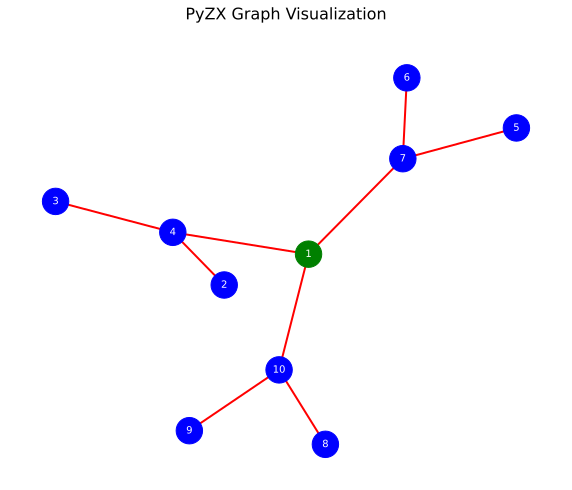

graph.html


In [14]:
nxg = nx.Graph()
bounds = []
for v in d["vertices"]:
    v_type = v["t"]
    if v["id"] in d["inputs"]:
        color = "green"
    else:
        color = "blue"
    if v_type != VertexType.BOUNDARY:
        nxg.add_node(v["id"], 
                    color=color, 
                    title=f"Type: {v_type.name}")
    else:
        bounds.append(v["id"])
        
for e in d["edges"]:
    vertexes = d["vertices"]
    edge_type = e[2]
    edge_color = "red" if edge_type == EdgeType.HADAMARD else "black"
    if e[0] not in bounds and e[1] not in bounds:
        nxg.add_edge(e[0], e[1])
        nxg[e[0]][e[1]]['color'] = edge_color

pos = nx.spring_layout(nxg, seed=42)  # nice spacing

node_colors = [nxg.nodes[n]['color'] for n in nxg.nodes()]
edge_colors = [nxg[u][v]['color'] for u,v in nxg.edges()]

# Draw the graph
plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(nxg, pos, node_color=node_colors, node_size=700)
nx.draw_networkx_edges(nxg, pos, edge_color=edge_colors, width=2)
nx.draw_networkx_labels(nxg, pos, font_size=10, font_color='white')

# Add title to the plot
plt.title("PyZX Graph Visualization", fontsize=16, pad=20)

plt.axis('off')
plt.show()

net = Network(notebook=True, directed=False)
net.from_nx(nxg)
net.toggle_physics(True)
net.show('graph.html')


In [8]:
nxg = nx.Graph()
bounds = []
for v in g["vertices"]:
    v_type = v["t"]
    if v["id"] in g["inputs"]:
        color = "green"
    else:
        color = "blue"
    if v_type != VertexType.BOUNDARY:
        nxg.add_node(v["id"], 
                    color=color, 
                    title=f"Type: {v_type.name}")
    else:
        bounds.append(v["id"])
        
for e in g["edges"]:
    vertexes = g["vertices"]
    edge_type = e[2]
    edge_color = "red" if edge_type == EdgeType.HADAMARD else "black"
    if e[0] not in bounds and e[1] not in bounds:
        nxg.add_edge(e[0], e[1])
        nxg[e[0]][e[1]]['color'] = edge_color

pos = nx.spring_layout(nxg, seed=42)  # nice spacing

node_colors = [nxg.nodes[n]['color'] for n in nxg.nodes()]
edge_colors = [nxg[u][v]['color'] for u,v in nxg.edges()]

# Draw the graph
plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(nxg, pos, node_color=node_colors, node_size=700)
nx.draw_networkx_edges(nxg, pos, edge_color=edge_colors, width=2)
nx.draw_networkx_labels(nxg, pos, font_size=10, font_color='white')

net = Network(notebook=False, directed=False)
net.from_nx(nxg)
net.toggle_physics(True)
net.show('graph.html')

plt.axis('off')
plt.show()


TypeError: 'GraphS' object is not subscriptable

In [ ]:
import networkx as nx
from pyvis.network import Network
import streamlit as st

def pyzx_graph_to_pyvis(g):
    nxg = nx.Graph()
    bounds = []
    for v in g["vertices"]:
        v_type = v["t"]
        if v["id"] in g["inputs"]:
            color = "green"
        else:
            color = "blue"
        if v_type != VertexType.BOUNDARY:
            nxg.add_node(v["id"], 
                        label=str(v), 
                        color=color, 
                        title=f"Type: {v_type.name}")
        else:
            bounds.append(v["id"])
            
    for e in g["edges"]:
        vertexes = g["vertices"]
        edge_type = e[2]
        edge_color = "red" if edge_type == EdgeType.HADAMARD else "black"
        if e[0] not in bounds and e[1] not in bounds:
            nxg.add_edge(e[0], e[1])
            nxg[e[0]][e[1]]['color'] = edge_color


    nx.draw_networkx(nxg)
    # # Create PyVis network
    net = Network(notebook=False, directed=False)
    net.from_nx(nxg)
    net.toggle_physics(True)
    net.show('graph.html')
    return net

    # net.show_buttons(filter_=['physics'])

    # html_path = "pyzx_graph.html"
    # net.save_graph(html_path)  # ✅ does not require render()

st.title("Tableau")

2025-09-26 13:07:23.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-26 13:07:23.736 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-26 13:07:23.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()